# Main Title
- Author: Maurice Roots
- Date Created: 2026-06-08 17:46
- Last Updated: 2026-06-08 17:46
--- 


In [12]:
import sys
from importlib import reload

from atmoz.surface.AirNow import AirNow
from atmoz.resources import useful_functions

reload(sys.modules['atmoz.surface.AirNow'])



<module 'atmoz.surface.AirNow' from 'e:\\Projects\\atmoz\\atmoz\\surface\\AirNow.py'>

In [2]:
AirNow

atmoz.surface.AirNow.AirNow

In [3]:
surface = AirNow.download(endpoint="aqs", parameters=["Ozone"], resolutions="hourly", years="2025")

In [4]:
surface.keys()

dict_keys(['hourly_44201_2025.csv'])

In [5]:
surface['hourly_44201_2025.csv'].columns

Index(['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Date Local',
       'Time Local', 'Date GMT', 'Time GMT', 'Sample Measurement',
       'Units of Measure', 'MDL', 'Uncertainty', 'Qualifier', 'Method Type',
       'Method Code', 'Method Name', 'State Name', 'County Name',
       'Date of Last Change'],
      dtype='str')

In [6]:
import pandas as pd 

def _make_datetime(df: pd.DataFrame,
                   time_cols: dict = {
                       "date": "Date GMT", 
                       "time": "Time GMT", 
                       "format": {"date": "%Y-%m-%d ", "time": "%H:%M"}
                       },
                    **kwargs
                    ):
    
    if not isinstance(time_cols, dict):
        raise TypeError("argument (time_cols) must be of type dict")
    if not isinstance(df, pd.DataFrame):
        raise TypeError("argument (df) must be of type pd.DataFrame")
    
    datetime = pd.to_datetime(
        df[time_cols["date"]] 
        + " "
        + df[time_cols["time"]], 
        format = time_cols["format"]["date"] + time_cols["format"]["time"]
        )

    return datetime 

surface_temp = surface['hourly_44201_2025.csv'].copy()
surface_temp["Datetime"] = _make_datetime(surface_temp)


In [7]:
from typing import Any, Dict, List, Optional, Tuple, Union
from atmoz.resources.timeConversions import format_resolution
reload(sys.modules['atmoz.resources.timeConversions'])

import geopandas as gpd

def get_resolution(df: pd.DataFrame, col1: str, col2: str, col3: str, time_col: str = "Time GMT") -> pd.DataFrame:
    group_cols = [col1, col2, col3]
    results = []

    for key, group in df.groupby(group_cols, sort=False):
        group = group.sort_values(time_col).reset_index(drop=True)

        if len(group) < 2:
            resolution = "unknown"
        else:
            delta = group[time_col].iloc[1] - group[time_col].iloc[0]
            resolution = format_resolution(delta)

        row = dict(zip(group_cols, key if isinstance(key, tuple) else (key,)))
        row["resolution"] = resolution
        results.append(row)

    return pd.DataFrame(results)

def _get_stations(df: pd.DataFrame, station_cols: List = ['State Code', 'County Code', 'Site Num']) -> List[Tuple]:
    return df[station_cols].drop_duplicates().tolist()

def _get_stations(df: pd.DataFrame, lat_lon: List = ['Latitude', 'Longitude']) -> List[Tuple]:
    return df[lat_lon].drop_duplicates().apply(tuple, axis=1).tolist()

def _metadata(df: pd.DataFrame, 
              data_columns: List = [
                  'Date Local',
                  'Time Local', 
                  'Date GMT', 
                  'Time GMT', 
                  'Sample Measurement'
                  ],
                LatLon_cols: List = ['Latitude', 'Longitude'],
                **kwargs):

    return df.drop(columns=data_columns).drop_duplicates(subset=LatLon_cols).reset_index(drop=True)

def to_gdf(df: pd.DataFrame, Latitude: str = "Latitude", Longitude: str = "Longitude", crs="EPSG:4326", **kwargs):
    geometry = gpd.points_from_xy(df[Longitude], df[Latitude])
    return gpd.GeoDataFrame(df, geometry=geometry, crs=crs, **kwargs)

In [8]:
df = surface_temp.copy() 
metadata = to_gdf(_metadata(df))

In [203]:
import plotly.graph_objects as go
from plotly.offline import iplot
import numpy as np

from itertools import cycle

colors = [
    "#CD6091",  # pink
    "#7195AB",  # steel blue
    "#6A4C93",  # purple
    "#4CC9F0",  # sky blue
    "#F4A261",  # orange
    "#2A9D8F",  # teal
    "#E76F51",  # burnt orange
    "#3A86FF",  # bright blue
    "#9B5DE5",  # violet
    "#8B3167",  # hot pink
]

def site_map(instruments: Dict,
             title: str = "Site Map",
             colors: list = colors,
             **kwargs
             ): 
    
    if not isinstance(instruments, Dict): 
        raise TypeError("'instruments' must be of type 'dict'")

    color_cycle = cycle(colors)

    params = {
        "bbox": {
            "lon": [-125.0, -66.9],
            "lat": [24.4, 49.4]
            },

        "title": {
            "text": title,
            "x": 0.5, "y": 0.98,
            "xanchor": "center",
            "font": dict(
                size=24,
                color="black",
                family="Arial Black"
                )
            },

        "map": {
            "zoom": 3,
            "bearing": 0,
            "pitch": 20,
            "domain": dict(x=[0, 1], y=[0, 1]),
            },

        "layout": {
            "height": 800,
            "width": 1600
            },
            
        "legend": dict(
            font=dict(size=18),
            itemsizing='constant',
            itemwidth=40,
            bgcolor='rgba(255,255,255,0.7)',
            x=0.01, y=0.99
            ),
        
        "Scattermap": {
            "mode": "markers",
            "marker": dict(size=15)
            },
        }
    
    params = useful_functions.merge_dicts(params, kwargs)
        
    fig = go.Figure()

    for name in instruments.keys():
        if not isinstance(instruments[name], gpd.GeoDataFrame):
            raise TypeError(f"'instruments' must be of type 'geopandas.GeoDataFrame'")

        trace_kwargs = {}
        hover_cols = kwargs.get("hover_cols", None)

        if hover_cols is not None:
            if isinstance(hover_cols, list):
                extra = "" if kwargs.get("show_trace_name", False) else "<extra></extra>"
                trace_kwargs = dict(
                    customdata=instruments[name][hover_cols],
                    hovertemplate="<br>".join(
                        f"<b>{col}</b>: %{{customdata[{i}]}}"
                        for i, col in enumerate(hover_cols)
                    ) + extra
                )

        marker = dict(params["Scattermap"]["marker"], color=params["Scattermap"]["marker"].get("color", next(color_cycle)))
        
        fig.add_trace(
            go.Scattermap( 
                lat=instruments[name].geometry.y,
                lon=instruments[name].geometry.x,
                name=name,
                mode=params["Scattermap"]["mode"],
                marker=marker,
                **trace_kwargs
                )
            )
        
    fig.update_layout(
        title=params["title"],
        map=dict(
            style="carto-positron",
            center=dict(
                lat=np.mean(params["bbox"]["lat"]),
                lon=np.mean(params["bbox"]["lon"])
                ),
            **params["map"],
            ),

        margin=dict(l=0, r=0, t=40, b=0),
        legend=params["legend"],
        showlegend=True,
        paper_bgcolor="rgba(255,255,255,0.7)",
        **params["layout"]
        )
    
    fig.show()
    return


In [204]:
site_map(instruments={"surface": metadata}, title = "EPA Air Quality Sites", map = {"zoom": 3, "pitch": 60}, hover_cols=["Site Num", "State Name", "County Name", "Latitude", "Longitude", "Parameter Name"])

In [101]:
def slice_bbox(gdf: gpd.GeoDataFrame, bbox: list) -> gpd.GeoDataFrame:
    return (
        gdf.cx[
            bbox["lon"][0]:bbox["lon"][1],
            bbox["lat"][0]:bbox["lat"][1]
        ]
        .reset_index(drop=True)
        )


In [102]:
bbox = {
    "lon": [-80.0, -73.0],
    "lat": [36.5, 42.5]
}

midAtlantic = slice_bbox(metadata, bbox=bbox)

In [ ]:
def _df_geo_slice(df: pd.DataFrame, gdf: gpd.GeoDataFrame, lat: str = "Latitude", lon: str = "Longitude") -> pd.DataFrame:
    coords = set(zip(gdf[lat], gdf[lon]))
    return df[pd.Series(zip(df[lat], df[lon])).isin(coords).values]

In [ ]:
df_midAtlantic = _df_geo_slice(df, midAtlantic)

In [205]:
site_map(
    instruments={"surface": midAtlantic},
    title = "MidAtlantic Region EPA Air Quality Sites", 
    map = {"zoom": 6, "pitch": 50},
    bbox= {"lon": [-80.0, -73.0], "lat": [36.5, 42.5]},
    hover_cols=["Site Num", "State Name", "County Name", "Latitude", "Longitude", "Parameter Name"]
    )


In [206]:
def _split_parameters(df: pd.DataFrame, parameter_col: str = 'Parameter Name') -> dict:
    return {param: df[df[parameter_col] == param] for param in df[parameter_col].unique()}

In [207]:
dict_midAtlantic = _split_parameters(df_midAtlantic)

In [208]:
dict_midAtlantic.keys()

dict_keys(['Ozone'])

<Axes: xlabel='Datetime'>

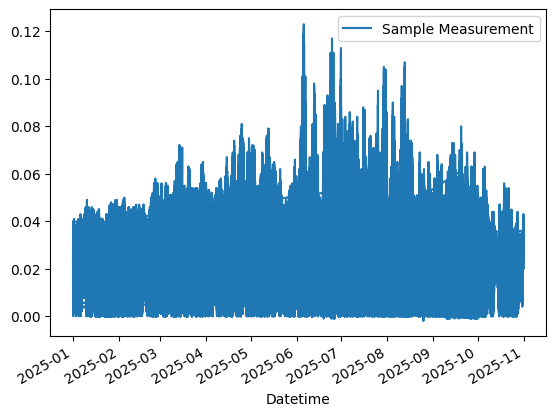

In [210]:
dict_midAtlantic["Ozone"].plot(x="Datetime", y="Sample Measurement")

In [ ]:
# def time_series(x, y,
#                 plot_params: Dict = {}, 
#                 theme: Dict = {},
#                 show=True
#                 **kwargs
#                 ):
    
#     theme = useful_functions.merge_dicts(time_series_profile_theme, theme)
#     plot_params = useful_functions.merge_dicts(time_series_profile_params, plot_params)

#     with plt.rc_context(theme):
#         fig, ax = plt.subplots()

#     figure, ax = plt.figure()

#     plt.plot(x,y, "--o")

NameError: name 'plot_utilities' is not defined

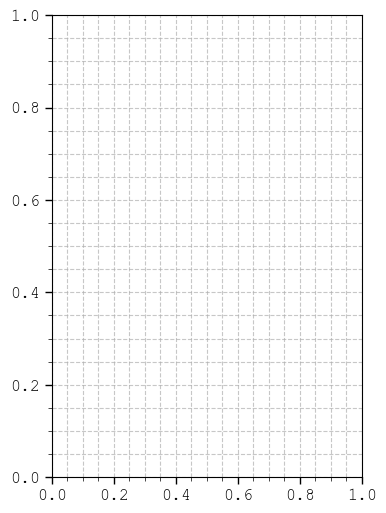

In [212]:
import matplotlib.pyplot as plt 
from atmoz.resources.plot_utilities import apply_plot_params, apply_datetime_axis

timeseries_plot_theme = {
            # ime_Tick label font sizes
            "xtick.labelsize": 12,      # previously params["fontsize_ticks"]
            "ytick.labelsize": 12,

            # Axes labels
            "axes.labelsize": 14,       # previously params["fontsize_label"]

            # Title font
            "axes.titlesize": 16,       # previously params["title"]["fontsize"]
            "axes.titleweight": "bold",

            # Grid style
            "axes.grid": True,
            "grid.linestyle": "--",
            "grid.alpha": 0.7,
            "axes.grid.which": "both",

            # Minor ticks
            "xtick.minor.visible": True,
            "ytick.minor.visible": True,
            "xtick.minor.size": 3,
            "ytick.minor.size": 3,
            "xtick.minor.width": 0.5,
            "ytick.minor.width": 0.5,

            # Major ticks
            "xtick.major.size": 5,
            "ytick.major.size": 5,
            "xtick.major.width": 1,
            "ytick.major.width": 1,

            # Figure size (optional)
            "figure.figsize": (20, 6),

            # Fonts
            "font.family": "Courier New",
            "font.size": 14
            }

timeseries_theme = useful_functions.merge_dicts(timeseries_plot_theme, {
    "figure.figsize": (4, 6)
    })


timeseries_params = {
    "ax.set_ylim": [0, 5],

    "ax.legend": {
        "loc": "upper left",
        "fontsize": 12
        },

    "ax.set_ylabel": {
        "ylabel": "Altitude (km ASL)"
        },

    "ax.set_xlabel": {
        "xlabel": "Ozone Mixing Ratio (ppbv)"
        },

    "ax.set_title": {
        "label": "Vertical Profile (distance <10km)",
        "fontsize": 12
        },

    "ax.grid": {
        "visible": True,
        "color": "gray",
        "linestyle": "--",
        "linewidth": 0.5
        },
    "fig.layout": "tight",
    }

theme = {}; plot_params = {}
theme = useful_functions.merge_dicts(timeseries_theme, theme)
plot_params = useful_functions.merge_dicts(timeseries_params, plot_params)

with plt.rc_context(theme):
    fig, ax = plt.subplots()


plot_utilities.apply_datetime_axis(ax, tz=tz)

plot_utilities.apply_plot_params(fig, ax, **params)
    